In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import pandas as pd

df = pd.read_csv("C:/Projects/1/Superstore_Cleaned.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Unnamed: 18,Year,Month,Month Number,Sales Category,Shipping Days
0,2698,CA-2015-145317,18/03/2015,23/03/2015,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,NaN,2015,March,3,High Sales,5
1,6827,CA-2017-118689,02/10/2017,09/10/2017,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,NaN,2017,October,10,High Sales,7
2,8154,CA-2018-140151,23/03/2018,25/03/2018,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,NaN,2018,March,3,High Sales,2
3,2624,CA-2018-127180,22/10/2018,24/10/2018,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,NaN,2018,October,10,High Sales,2
4,4191,CA-2018-166709,17/11/2018,22/11/2018,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,NaN,2018,November,11,High Sales,5


In [10]:
df.shape

(9800, 24)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9800 non-null   int64  
 1   Order ID        9800 non-null   object 
 2   Order Date      9800 non-null   object 
 3   Ship Date       9800 non-null   object 
 4   Ship Mode       9800 non-null   object 
 5   Customer ID     9800 non-null   object 
 6   Customer Name   9800 non-null   object 
 7   Segment         9800 non-null   object 
 8   Country         9800 non-null   object 
 9   City            9800 non-null   object 
 10  State           9800 non-null   object 
 11  Postal Code     9800 non-null   object 
 12  Region          9800 non-null   object 
 13  Product ID      9800 non-null   object 
 14  Category        9800 non-null   object 
 15  Sub-Category    9800 non-null   object 
 16  Product Name    9800 non-null   object 
 17  Sales           9800 non-null   f

In [12]:
df.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
Country              0
City                 0
State                0
Postal Code          0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Unnamed: 18       9800
Year                 0
Month                0
Month Number         0
Sales Category       0
Shipping Days        0
dtype: int64

In [13]:
df.shape

(9800, 24)

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [15]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index()
monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

monthly_sales.head()

,Order Date,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


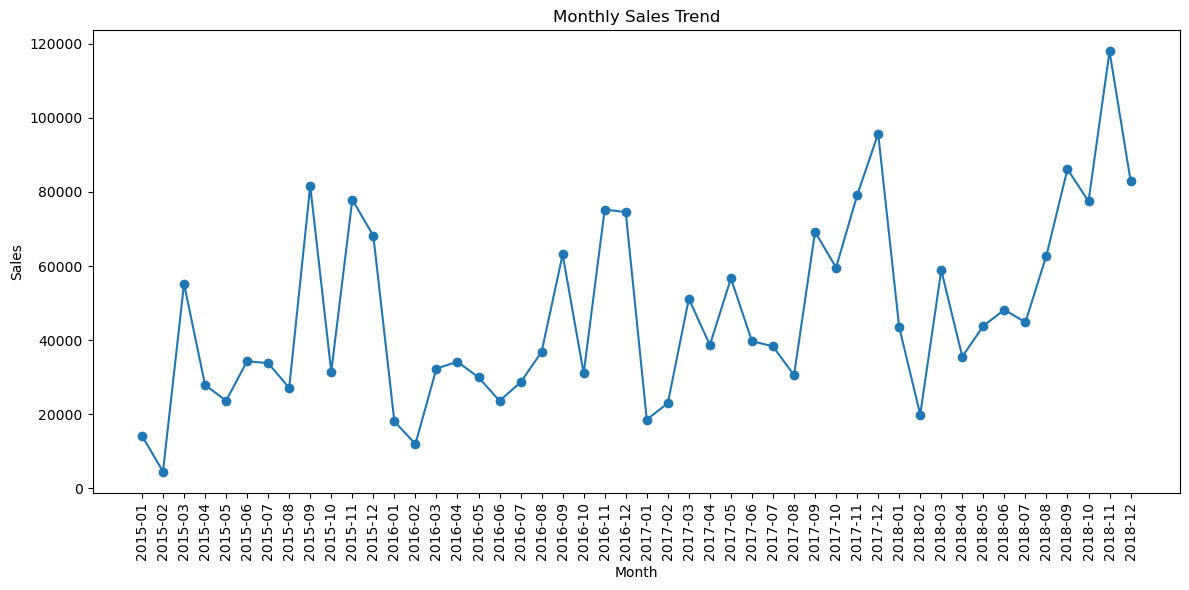

In [16]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
monthly_sales.head()

,Order Date,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


In [18]:
monthly_sales.tail()

,Order Date,Sales
43,2018-08,62837.8480
44,2018-09,86152.8880
45,2018-10,77448.1312
46,2018-11,117938.1550
47,2018-12,83030.3888


In [19]:
monthly_sales.shape

(48, 2)

In [20]:
monthly_sales_by_month = df.groupby("Month Number")["Sales"].sum().reset_index()

monthly_sales_by_month

,Month Number,Sales
0,1,94291.6296
1,2,59371.1154
2,3,197573.5872
3,4,136283.0006
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
7,8,157315.9270
8,9,300103.4117
9,10,199496.2947


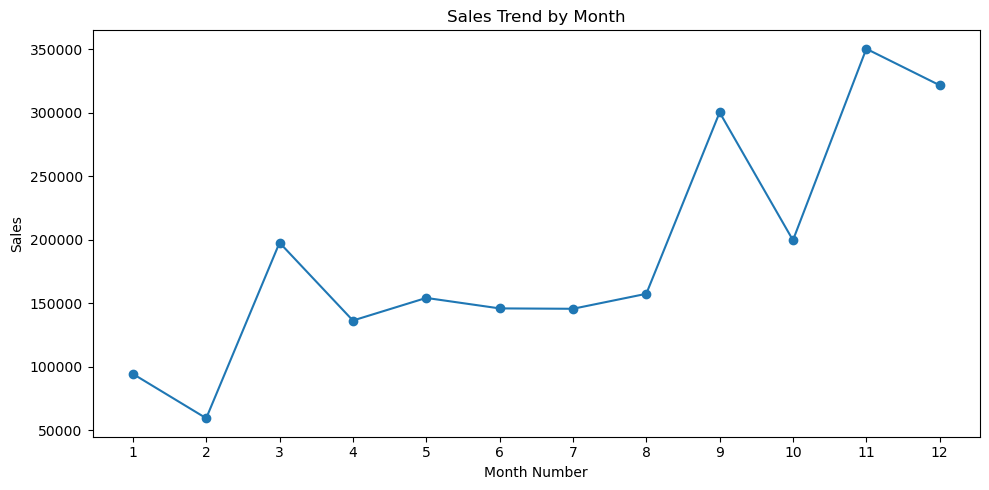

In [21]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales_by_month["Month Number"], monthly_sales_by_month["Sales"], marker="o")
plt.title("Sales Trend by Month")
plt.xlabel("Month Number")
plt.ylabel("Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Unnamed: 18', 'Year', 'Month', 'Month Number',
       'Sales Category', 'Shipping Days'],
      dtype='object')

In [24]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Unnamed: 18,Year,Month Number,Shipping Days
count,9800.000000,9800,9800,9800.000000,0.0,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,230.769059,NaN,2016.724184,7.818469,3.961122
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.444000,NaN,2015.000000,1.000000,0.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,17.248000,NaN,2016.000000,5.000000,3.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,54.490000,NaN,2017.000000,9.000000,4.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,210.605000,NaN,2018.000000,11.000000,5.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,22638.480000,NaN,2018.000000,12.000000,7.000000
std,2829.160653,NaN,NaN,626.651875,NaN,1.123984,3.281905,1.749614


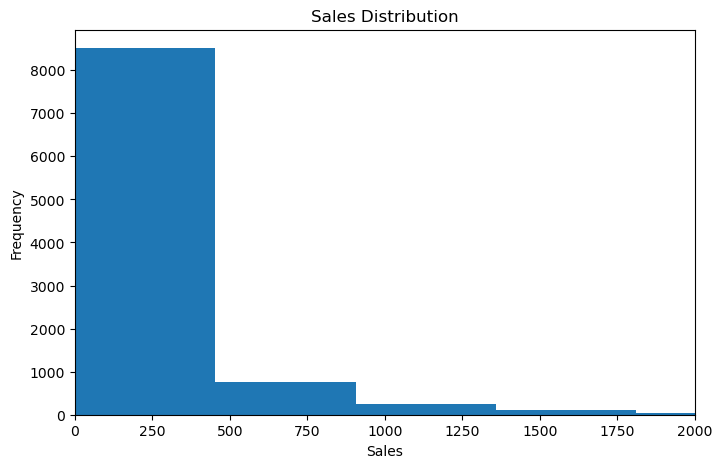

In [55]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=50)

plt.xlim(0,2000)

plt.title("Sales Distribution")

plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [27]:
shipping_stats = df["Shipping Days"].describe()

shipping_stats

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [28]:
shipping_mode_analysis = df.groupby("Ship Mode")["Shipping Days"].mean().reset_index()

shipping_mode_analysis

,Ship Mode,Shipping Days
0,First Class,2.179214
1,Same Day,0.044610
2,Second Class,3.249211
3,Standard Class,5.008363


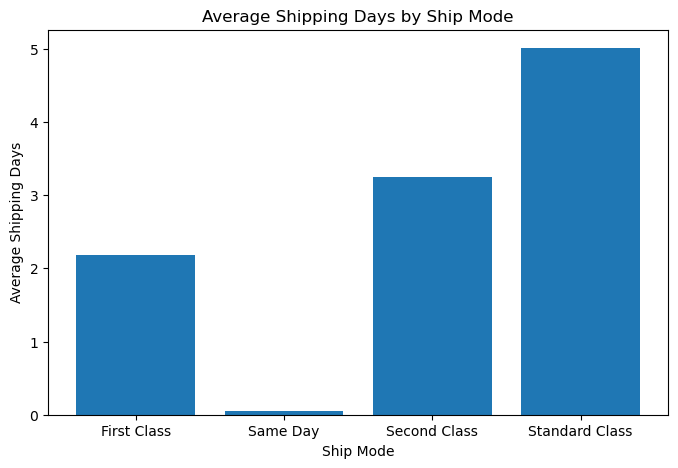

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_mode_analysis["Ship Mode"],
    shipping_mode_analysis["Shipping Days"]
)

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.show()

In [30]:
customer_sales = df.groupby("Customer Name")["Sales"].sum()

customer_sales.describe()

count      793.000000
mean      2851.874884
std       2620.668723
min          4.833000
25%       1081.466000
50%       2215.002000
75%       3670.258000
max      25043.050000
Name: Sales, dtype: float64

In [31]:
top_customers = df.groupby("Customer Name")["Sales"].sum().reset_index()

top_customers = top_customers.sort_values(
    by="Sales",
    ascending=False
)

top_customers.head(10)

,Customer Name,Sales
686,Sean Miller,25043.050
730,Tamara Chand,19052.218
622,Raymond Buch,15117.339
757,Tom Ashbrook,14595.620
6,Adrian Barton,14473.571
441,Ken Lonsdale,14175.229
671,Sanjit Chand,14142.334
334,Hunter Lopez,12873.298
672,Sanjit Engle,12209.438
156,Christopher Conant,12129.072


In [32]:
regional_sales = df.groupby("Region")["Sales"].sum().reset_index()

regional_sales

,Region,Sales
0,Central,492646.9132
1,East,669518.7260
2,South,389151.4590
3,West,710219.6845


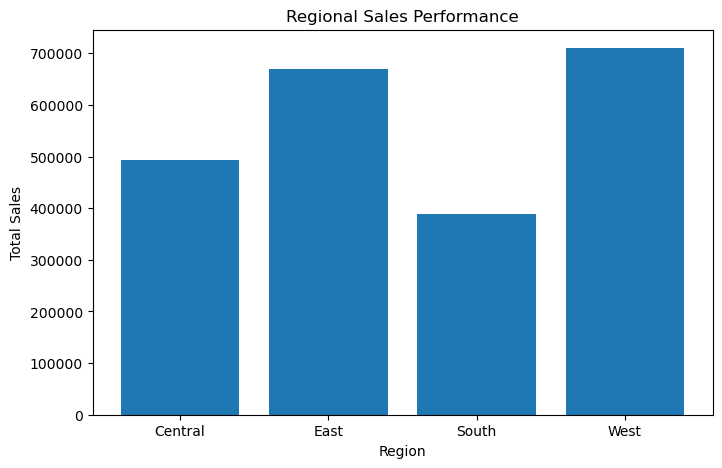

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    regional_sales["Region"],
    regional_sales["Sales"]
)

plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

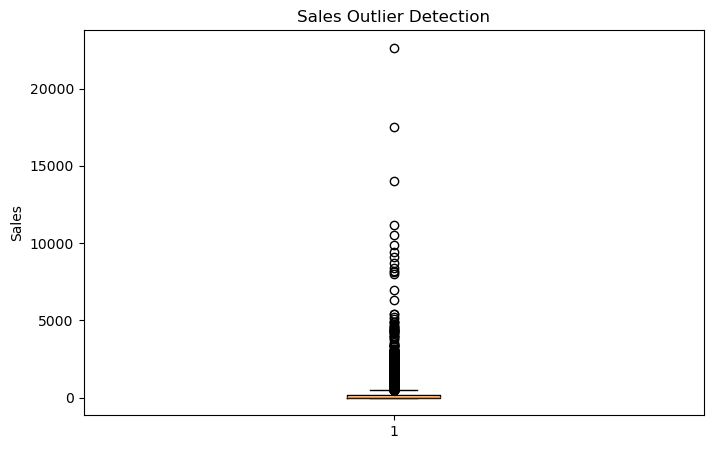

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"])

plt.title("Sales Outlier Detection")

plt.ylabel("Sales")

plt.show()

In [36]:
customer_sales = df.groupby("Customer Name")["Sales"].sum()

customer_sales.describe()

count      793.000000
mean      2851.874884
std       2620.668723
min          4.833000
25%       1081.466000
50%       2215.002000
75%       3670.258000
max      25043.050000
Name: Sales, dtype: float64

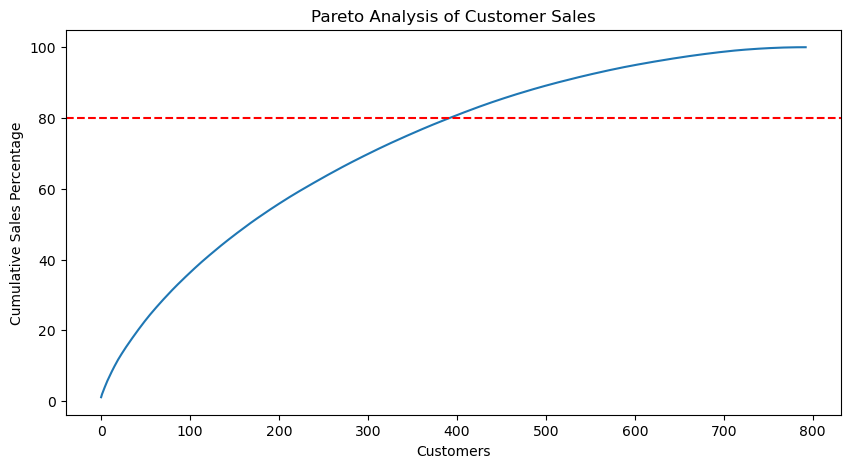

In [37]:
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

cumulative_sales = customer_sales.cumsum() / customer_sales.sum() * 100

plt.figure(figsize=(10,5))

plt.plot(range(len(cumulative_sales)), cumulative_sales)

plt.axhline(y=80, color='r', linestyle='--')

plt.title("Pareto Analysis of Customer Sales")
plt.xlabel("Customers")
plt.ylabel("Cumulative Sales Percentage")

plt.show()

In [38]:
customer_orders = df["Customer Name"].value_counts()

customer_orders.head(10)

Customer Name
William Brown          35
Matt Abelman           34
Paul Prost             34
John Lee               33
Chloris Kastensmidt    32
Seth Vernon            32
Jonathan Doherty       32
Emily Phan             31
Zuschuss Carroll       31
Arthur Prichep         31
Name: count, dtype: int64

In [39]:
df["Shipping Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

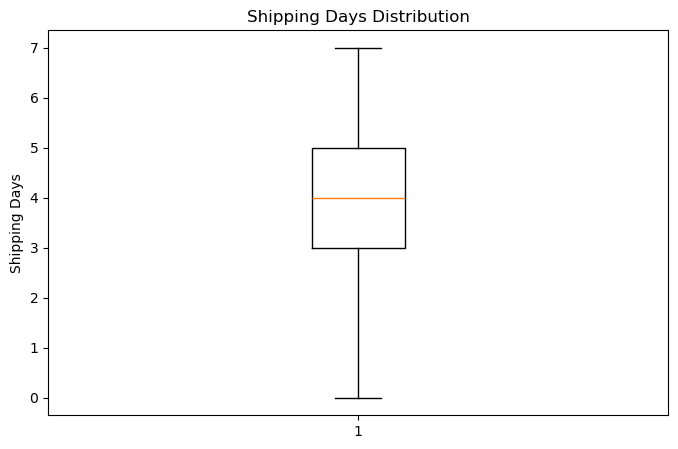

In [40]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Shipping Days"])

plt.title("Shipping Days Distribution")

plt.ylabel("Shipping Days")

plt.show()

In [42]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index()

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

monthly_sales.head()

,Order Date,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


In [43]:
monthly_sales["Month_Index"] = range(1, len(monthly_sales)+1)

monthly_sales.head()

,Order Date,Sales,Month_Index
0,2015-01,14205.707,1
1,2015-02,4519.892,2
2,2015-03,55205.797,3
3,2015-04,27906.855,4
4,2015-05,23644.303,5


In [44]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [45]:
X = monthly_sales[["Month_Index"]]

y = monthly_sales["Sales"]

In [46]:
model = LinearRegression()

model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
monthly_sales["Predicted_Sales"] = model.predict(X)

monthly_sales.head()

,Order Date,Sales,Month_Index,Predicted_Sales
0,2015-01,14205.707,1,26240.013137
1,2015-02,4519.892,2,27128.325329
2,2015-03,55205.797,3,28016.637521
3,2015-04,27906.855,4,28904.949712
4,2015-05,23644.303,5,29793.261904


In [48]:
future_months = pd.DataFrame({
    "Month_Index": range(len(monthly_sales)+1, len(monthly_sales)+7)
})

future_predictions = model.predict(future_months)

future_predictions

array([68878.99833333, 69767.31052491, 70655.6227165 , 71543.93490808,
       72432.24709966, 73320.55929124])

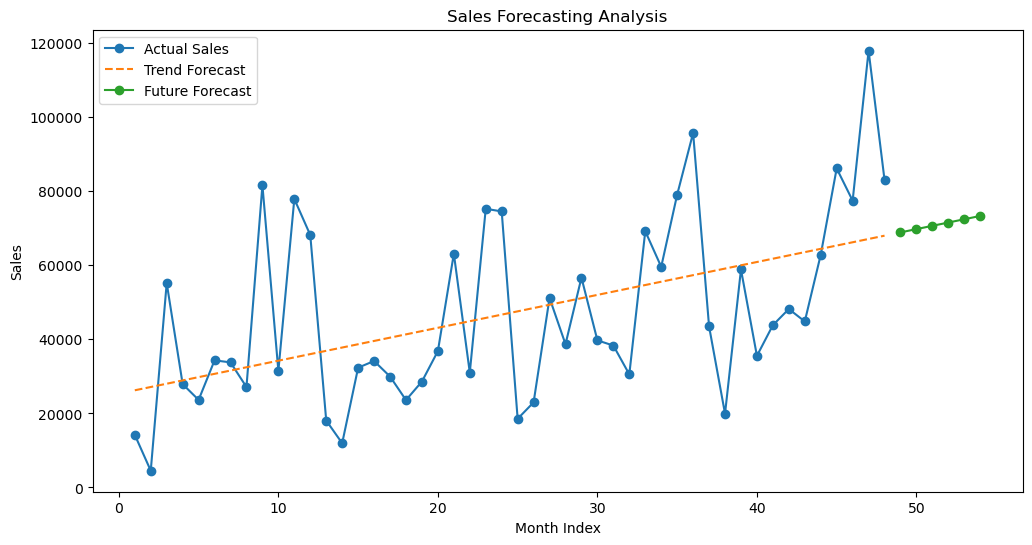

In [49]:
plt.figure(figsize=(12,6))

# Actual sales
plt.plot(
    monthly_sales["Month_Index"],
    monthly_sales["Sales"],
    label="Actual Sales",
    marker="o"
)

# Trend line
plt.plot(
    monthly_sales["Month_Index"],
    monthly_sales["Predicted_Sales"],
    label="Trend Forecast",
    linestyle="--"
)

# Future forecast
plt.plot(
    future_months["Month_Index"],
    future_predictions,
    label="Future Forecast",
    marker="o"
)

plt.title("Sales Forecasting Analysis")

plt.xlabel("Month Index")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [50]:
customer_sales = df.groupby("Customer Name")["Sales"].sum().reset_index()

customer_sales.head()

,Customer Name,Sales
0,Aaron Bergman,886.156
1,Aaron Hawkins,1744.700
2,Aaron Smayling,3050.692
3,Adam Bellavance,7755.620
4,Adam Hart,3250.337


In [51]:
customer_sales = customer_sales.sort_values(
    by="Sales",
    ascending=False
)

customer_sales.head(10)

,Customer Name,Sales
686,Sean Miller,25043.050
730,Tamara Chand,19052.218
622,Raymond Buch,15117.339
757,Tom Ashbrook,14595.620
6,Adrian Barton,14473.571
441,Ken Lonsdale,14175.229
671,Sanjit Chand,14142.334
334,Hunter Lopez,12873.298
672,Sanjit Engle,12209.438
156,Christopher Conant,12129.072


In [52]:
customer_sales["Sales"].describe()

count      793.000000
mean      2851.874884
std       2620.668723
min          4.833000
25%       1081.466000
50%       2215.002000
75%       3670.258000
max      25043.050000
Name: Sales, dtype: float64

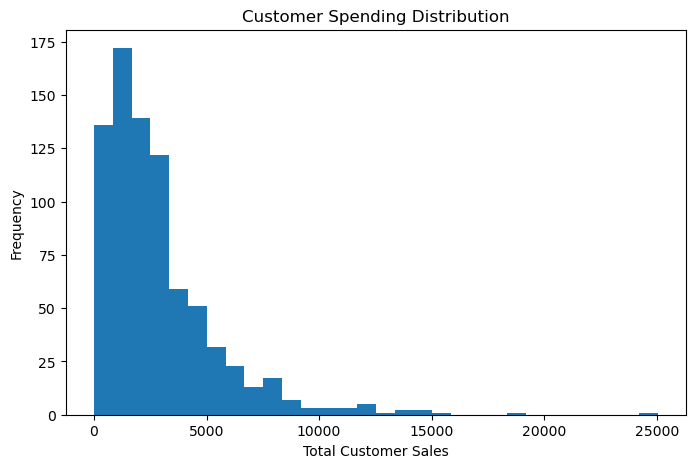

In [53]:
plt.figure(figsize=(8,5))

plt.hist(customer_sales["Sales"], bins=30)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Customer Sales")

plt.ylabel("Frequency")

plt.show()